## Construcción inicial del Índice de Agotamiento Inmunológico (IAI)
# Fase I in silico




# Notebook 01 — Diseño inicial del Índice de Agotamiento Inmunológico (IAI)
# Proyecto: iai-tools
#
## Objetivo:
 Definir la estructura base del IAI como herramienta portable y multimodal, incluyendo marcadores, equivalencias entre técnicas, reglas de cobertura y formato esperado de entrada.

# Importar librerias

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix



# Configuración inicial

In [28]:
RANDOM_STATE = 42

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

RESULTS_DIR = BASE_DIR / "results"
WEIGHTS_DIR = RESULTS_DIR / "weights"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

for folder in [
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_DIR,
    WEIGHTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Directorio base:", BASE_DIR)
print("Datos crudos:", RAW_DATA_DIR)
print("Datos procesados:", PROCESSED_DATA_DIR)
print("Resultados:", RESULTS_DIR)

Directorio base: c:\Users\evgen\Documents\Desktop_pet\IAI
Datos crudos: c:\Users\evgen\Documents\Desktop_pet\IAI\data\raw
Datos procesados: c:\Users\evgen\Documents\Desktop_pet\IAI\data\processed
Resultados: c:\Users\evgen\Documents\Desktop_pet\IAI\results


# Catálogo de marcadores



El IAI se basa en un conjunto estructurado de biomarcadores asociados al agotamiento de linfocitos T.
Cada marcador representa una dimensión específica del estado de disfunción inmunológica.(Estos datos se modificaran con base en los datos del metanalisis)

### **Dominios biológicos**

* **Phenotypic:**
  Receptores inhibitorios de superficie (PD-1, TIM-3, LAG-3, CD39, CD73)

* **Functional:**
  Citocinas inmunosupresoras (IL-10, TGF-β)

* **Transcriptional program:**
  Reguladores del estado exhausto (TOX, TCF-1)

* **Signaling:**
  Vías intracelulares activadas (p-STAT3)



### **Campos del catálogo**

* **marker_id**
  Identificador interno del marcador

* **gene**
  Nombre del gen (para datos transcriptómicos)

* **protein**
  Nombre del marcador a nivel proteico

* **domain**
  Dimensión biológica del marcador

* **core**
  Marcadores esenciales para el cálculo del IAI-core

* **expected_direction**
  Relación esperada con el agotamiento
  (↑ = mayor agotamiento)

* **possible_modalities**
  Técnicas en las que puede medirse:

  * `rna`
  * `flow`
  * `elisa`
  * `western_blot`
  * `flow_intracellular`


In [29]:
marker_catalog = pd.DataFrame([
    {
        "marker_id": "PD1",
        "gene": "PDCD1",
        "protein": "PD-1",
        "domain": "phenotypic",
        "core": True,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["rna", "flow"],
    },
    {
        "marker_id": "CD39",
        "gene": "ENTPD1",
        "protein": "CD39",
        "domain": "phenotypic",
        "core": True,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["rna", "flow"],
    },
    {
        "marker_id": "TIM3",
        "gene": "HAVCR2",
        "protein": "TIM-3",
        "domain": "phenotypic",
        "core": False,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["rna", "flow"],
    },
    {
        "marker_id": "LAG3",
        "gene": "LAG3",
        "protein": "LAG-3",
        "domain": "phenotypic",
        "core": False,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["rna", "flow"],
    },
    {
        "marker_id": "CD73",
        "gene": "NT5E",
        "protein": "CD73",
        "domain": "phenotypic",
        "core": False,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["rna", "flow"],
    },
    {
        "marker_id": "TOX",
        "gene": "TOX",
        "protein": "TOX",
        "domain": "transcriptional_program",
        "core": True,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["rna", "western_blot", "flow_intracellular"],
    },
    {
        "marker_id": "TCF1",
        "gene": "TCF7",
        "protein": "TCF-1",
        "domain": "transcriptional_program",
        "core": False,
        "expected_direction": "context_dependent",
        "possible_modalities": ["rna", "western_blot", "flow_intracellular"],
    },
    {
        "marker_id": "IL10",
        "gene": "IL10",
        "protein": "IL-10",
        "domain": "functional",
        "core": True,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["rna", "elisa"],
    },
    {
        "marker_id": "TGFB1",
        "gene": "TGFB1",
        "protein": "TGF-beta",
        "domain": "functional",
        "core": True,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["rna", "elisa"],
    },
    {
        "marker_id": "IL6",
        "gene": "IL6",
        "protein": "IL-6",
        "domain": "functional_inflammatory_context",
        "core": False,
        "expected_direction": "context_dependent",
        "possible_modalities": ["rna", "elisa"],
    },
    {
        "marker_id": "PSTAT3",
        "gene": None,
        "protein": "p-STAT3/STAT3",
        "domain": "signaling",
        "core": True,
        "expected_direction": "increase_with_exhaustion",
        "possible_modalities": ["western_blot"],
    },
])

marker_catalog

,marker_id,gene,protein,domain,core,expected_direction,possible_modalities
0,PD1,PDCD1,PD-1,phenotypic,True,increase_with_exhaustion,"[rna, flow]"
1,CD39,ENTPD1,CD39,phenotypic,True,increase_with_exhaustion,"[rna, flow]"
2,TIM3,HAVCR2,TIM-3,phenotypic,False,increase_with_exhaustion,"[rna, flow]"
3,LAG3,LAG3,LAG-3,phenotypic,False,increase_with_exhaustion,"[rna, flow]"
4,CD73,NT5E,CD73,phenotypic,False,increase_with_exhaustion,"[rna, flow]"
5,TOX,TOX,TOX,transcriptional_program,True,increase_with_exhaustion,"[rna, western_blot, flow_intracellular]"
6,TCF1,TCF7,TCF-1,transcriptional_program,False,context_dependent,"[rna, western_blot, flow_intracellular]"
7,IL10,IL10,IL-10,functional,True,increase_with_exhaustion,"[rna, elisa]"
8,TGFB1,TGFB1,TGF-beta,functional,True,increase_with_exhaustion,"[rna, elisa]"
9,IL6,IL6,IL-6,functional_inflammatory_context,False,context_dependent,"[rna, elisa]"


## **Formato de entrada del IAI**

El IAI acepta datos provenientes de diferentes modalidades experimentales.  
Cada muestra se representa como una fila y cada marcador como una columna.

### **Estructura general**

- Filas: muestras
- Columnas: biomarcadores
- Valores: cuantificación del marcador (dependiente de la técnica)


### **Convenciones de nombres**

Los nombres de columnas deben corresponder a:

- **Genes** (RNA-seq):  
  `PDCD1`, `ENTPD1`, `TOX`, `IL10`, etc.

- **Citometría de flujo:**  
  `PD1_MFI`, `CD39_percent`, etc.

- **ELISA:**  
  `IL10_pg_ml`, `TGFB1_pg_ml`

- **Western blot:**  
  `TOX_relative`, `pSTAT3_STAT3_ratio`

### **Ejemplo de input multimodal**

| sample_id | PDCD1 | ENTPD1 | TOX | IL10 | PD1_MFI | CD39_percent | IL10_pg_ml | TOX_relative |
|----------|------|--------|-----|------|--------|--------------|------------|--------------|
| S1       | 2.3  | 1.8    | 3.1 | 0.5  | 1200   | 45           | 32         | 1.2          |
| S2       | 0.8  | 0.6    | 1.0 | 0.2  | 400    | 10           | 8          | 0.5          |


### **Consideraciones**

- No todas las columnas son obligatorias
- El modelo utilizará únicamente los marcadores disponibles
- Se calculará un nivel de cobertura para cada muestra

### **Mapeo de equivalencias (a expandir)**


| Dominio | Gen    | Proteína | Input aceptado       |
| ------- | ------ | -------- | -------------------- |
| PD-1    | PDCD1  | PD-1     | PDCD1, PD1_MFI       |
| CD39    | ENTPD1 | CD39     | ENTPD1, CD39_percent |
| IL-10   | IL10   | IL-10    | IL10, IL10_pg_ml     |
| TOX     | TOX    | TOX      | TOX, TOX_relative    |



In [30]:
# Mapeo de equivalencias

feature_map = {
    "PD1": ["PDCD1", "PD1_MFI", "PD1_percent"],
    "CD39": ["ENTPD1", "CD39_MFI", "CD39_percent"],
    "TIM3": ["HAVCR2", "TIM3_MFI", "TIM3_percent"],
    "LAG3": ["LAG3", "LAG3_MFI", "LAG3_percent"],
    "CD73": ["NT5E", "CD73_MFI", "CD73_percent"],
    "TOX": ["TOX", "TOX_relative"],
    "TCF1": ["TCF7", "TCF1_relative"],
    "IL10": ["IL10", "IL10_pg_ml"],
    "TGFB1": ["TGFB1", "TGFB1_pg_ml"],
    "IL6": ["IL6", "IL6_pg_ml"],
    "PSTAT3": ["pSTAT3_STAT3_ratio"],
}

## **Validación del input del IAI**

Antes de calcular el índice, es necesario verificar que el dataset contiene los biomarcadores requeridos y determinar qué tan completo es el conjunto de datos.

### **¿Qué hace esta validación?**

La función de validación realiza cuatro tareas principales:

* **Identificación de marcadores disponibles**
  Detecta qué biomarcadores del catálogo están presentes en el dataset, considerando equivalencias entre técnicas (por ejemplo, `PDCD1` en RNA o `PD1_MFI` en citometría).

* **Selección de la variable representativa**
  Cuando existen múltiples columnas para un mismo marcador, se selecciona una para su uso en el modelo.

* **Clasificación por dominio biológico**
  Asigna cada marcador a su dimensión (fenotípica, funcional, transcripcional o de señalización).

* **Evaluación de cobertura del dataset**
  Calcula qué proporción de marcadores totales y marcadores esenciales (*core*) está disponible.

### **Resultado de la validación**

La validación genera dos salidas:

* **Tabla de validación (`validation_report`)**
  Resume qué marcadores están presentes, qué columna se usará y a qué dominio pertenecen.

* **Resumen del dataset (`summary`)**
  Incluye:

  * cobertura total
  * cobertura de marcadores esenciales
  * tipo de score que puede calcularse:

    * `full`
    * `core`
    * `approx`
  * nivel de confiabilidad

### **Interpretación**

* **IAI-full:**
  Alta cobertura de marcadores → score completo

* **IAI-core:**
  Solo marcadores esenciales disponibles → score simplificado

* **IAI-approx:**
  Información limitada → score estimado con menor confiabilidad



In [31]:
def detect_modality(column_name):
    """
    Detecta la modalidad experimental a partir del nombre de la columna.
    """
    if column_name is None:
        return None

    if "MFI" in column_name or "percent" in column_name:
        return "flow"
    elif "pg_ml" in column_name:
        return "elisa"
    elif "relative" in column_name or "ratio" in column_name:
        return "western_blot"
    else:
        return "rna"


def validate_input(df, feature_map, marker_catalog):
    

    detected = []

    for marker_id, possible_columns in feature_map.items():

        # Columnas del dataset que coinciden con las equivalencias aceptadas
        found_columns = [col for col in possible_columns if col in df.columns]

        if len(found_columns) > 0:
            available = True
            selected_column = found_columns[0]
            modality = detect_modality(selected_column)
        else:
            available = False
            selected_column = None
            modality = None

        # Información biológica desde el catálogo
        catalog_row = marker_catalog[marker_catalog["marker_id"] == marker_id]

        if not catalog_row.empty:
            domain = catalog_row["domain"].iloc[0]
            core = bool(catalog_row["core"].iloc[0])
        else:
            domain = None
            core = False

        detected.append({
            "marker_id": marker_id,
            "available": available,
            "selected_column": selected_column,
            "all_matching_columns": found_columns,
            "modality": modality,
            "domain": domain,
            "core": core,
        })

    validation_report = pd.DataFrame(detected)

    # Cálculo de cobertura

    total_markers = len(validation_report)
    available_markers = int(validation_report["available"].sum())

    core_markers = int(validation_report["core"].sum())
    available_core_markers = int(
        (validation_report["available"] & validation_report["core"]).sum()
    )

    coverage = available_markers / total_markers if total_markers > 0 else 0
    core_coverage = available_core_markers / core_markers if core_markers > 0 else 0

    # Clasificación del tipo de score posible

    if coverage >= 0.80 and core_coverage >= 0.80:
        score_type = "full"
        reliability = "high"
    elif core_coverage >= 0.60:
        score_type = "core"
        reliability = "moderate"
    else:
        score_type = "approx"
        reliability = "low"

    summary = {
        "total_markers": int(total_markers),
        "available_markers": int(available_markers),
        "coverage": round(float(coverage), 3),
        "core_markers": int(core_markers),
        "available_core_markers": int(available_core_markers),
        "core_coverage": round(float(core_coverage), 3),
        "score_type": score_type,
        "reliability": reliability,
    }

    return validation_report, summary

In [32]:
# Dataset de ejemplo para probar la validación
example_df = pd.DataFrame({
    "sample_id": ["S1", "S2", "S3"],
    "PDCD1": [2.3, 1.2, 3.4],
    "ENTPD1": [1.5, 0.9, 2.1],
    "TOX": [3.2, 1.1, 2.9],
    "IL10_pg_ml": [30, 10, 45],
    "TGFB1_pg_ml": [120, 80, 160],
    "pSTAT3_STAT3_ratio": [1.2, 0.8, 1.5],
})

validation_report, summary = validate_input(
    df=example_df,
    feature_map=feature_map,
    marker_catalog=marker_catalog
)

validation_report
summary

{'total_markers': 11,
 'available_markers': 6,
 'coverage': 0.545,
 'core_markers': 6,
 'available_core_markers': 6,
 'core_coverage': 1.0,
 'score_type': 'core',
 'reliability': 'moderate'}

## Normalización de datos (despues se analizara mejor que datos tienes mas peso y si este metodo es correcto)

Después de validar qué marcadores están disponibles, los valores deben transformarse a una escala común para calcular el IAI.

La normalización permite integrar datos provenientes de distintas modalidades experimentales, como RNA-seq, citometría de flujo, ELISA y Western blot.

En esta versión inicial se utiliza escalamiento min–max, que transforma cada variable al rango 0–1:

\[
x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}
\]

Esto permite que todos los marcadores contribuyan al índice en una escala comparable.

In [33]:
def normalize_input(df, validation_report):
    
    available_features = validation_report[
        validation_report["available"] == True
    ].copy()

    normalized_data = {}
    params = []

    for _, row in available_features.iterrows():
        marker_id = row["marker_id"]
        column = row["selected_column"]

        values = pd.to_numeric(df[column], errors="coerce")

        min_value = values.min()
        max_value = values.max()

        if pd.isna(min_value) or pd.isna(max_value):
            normalized_values = np.nan
        elif max_value == min_value:
            normalized_values = 0.0
        else:
            normalized_values = (values - min_value) / (max_value - min_value)

        normalized_data[marker_id] = normalized_values

        params.append({
            "marker_id": marker_id,
            "source_column": column,
            "min_value": min_value,
            "max_value": max_value,
            "modality": row["modality"],
            "domain": row["domain"],
            "core": row["core"],
        })

    normalized_df = pd.DataFrame(normalized_data, index=df.index)
    normalization_params = pd.DataFrame(params)

    return normalized_df, normalization_params

In [34]:
normalized_df, normalization_params = normalize_input(
    df=example_df,
    validation_report=validation_report
)

normalized_df

,PD1,CD39,TOX,IL10,TGFB1,PSTAT3
0,0.5,0.5,1.000000,0.571429,0.5,0.571429
1,0.0,0.0,0.000000,0.000000,0.0,0.000000
2,1.0,1.0,0.857143,1.000000,1.0,1.000000


## Definición inicial de pesos del IAI

En esta etapa inicial se definen pesos provisionales para probar el cálculo del IAI antes del entrenamiento definitivo del modelo.

Los pesos se asignan por dominio biológico:

- Fenotípico: marcadores de superficie asociados al agotamiento T.
- Funcional: citocinas inmunosupresoras.
- Programa transcripcional: reguladores del estado exhausto.
- Señalización: proteínas asociadas a vías intracelulares.

Estos pesos serán reemplazados posteriormente por pesos derivados del modelo entrenado con datos públicos y metaanálisis

In [35]:
domain_weights = {
    "phenotypic": 0.35,
    "functional": 0.25,
    "functional_inflammatory_context": 0.10,
    "transcriptional_program": 0.20,
    "signaling": 0.10,
}

domain_weights

{'phenotypic': 0.35,
 'functional': 0.25,
 'functional_inflammatory_context': 0.1,
 'transcriptional_program': 0.2,
 'signaling': 0.1}

In [36]:
def assign_initial_weights(validation_report, domain_weights):
    

    available = validation_report[
        validation_report["available"] == True
    ].copy()

    weights = []

    for domain, domain_weight in domain_weights.items():
        domain_features = available[available["domain"] == domain]

        if domain_features.empty:
            continue

        per_marker_weight = domain_weight / len(domain_features)

        for _, row in domain_features.iterrows():
            weights.append({
                "marker_id": row["marker_id"],
                "selected_column": row["selected_column"],
                "domain": row["domain"],
                "modality": row["modality"],
                "core": row["core"],
                "weight": per_marker_weight,
            })

    weights_df = pd.DataFrame(weights)

    # Reescalar pesos para que sumen 1 si faltan dominios o marcadores
    if not weights_df.empty:
        weights_df["weight"] = weights_df["weight"] / weights_df["weight"].sum()

    return weights_df

In [37]:
initial_weights = assign_initial_weights(
    validation_report=validation_report,
    domain_weights=domain_weights
)

initial_weights

,marker_id,selected_column,domain,modality,core,weight
0,PD1,PDCD1,phenotypic,rna,True,0.194444
1,CD39,ENTPD1,phenotypic,rna,True,0.194444
2,IL10,IL10_pg_ml,functional,elisa,True,0.138889
3,TGFB1,TGFB1_pg_ml,functional,elisa,True,0.138889
4,TOX,TOX,transcriptional_program,rna,True,0.222222
5,PSTAT3,pSTAT3_STAT3_ratio,signaling,western_blot,True,0.111111


## Cálculo del Índice de Agotamiento Inmunológico (IAI)

Una vez normalizados los marcadores y definidos los pesos, el IAI se calcula como una suma ponderada:

\[
IAI = \sum_{i=1}^{n} w_i \cdot x_i^{norm}
\]

donde:

- \(x_i^{norm}\) es el valor normalizado del marcador.
- \(w_i\) es el peso asignado al marcador.
- El resultado final se expresa en una escala de 0 a 1.

En esta versión inicial, los pesos son provisionales y se asignan por dominio biológico. Posteriormente serán reemplazados por pesos derivados del modelo entrenado con datos públicos y de metanálisis

In [38]:
def compute_iai(normalized_df, weights_df):

    if normalized_df.empty:
        raise ValueError("normalized_df está vacío.")

    if weights_df.empty:
        raise ValueError("weights_df está vacío.")

    required_columns = {"marker_id", "weight"}
    missing_columns = required_columns - set(weights_df.columns)

    if missing_columns:
        raise ValueError(f"Faltan columnas en weights_df: {missing_columns}")

    markers_in_weights = weights_df["marker_id"].tolist()
    available_markers = [m for m in markers_in_weights if m in normalized_df.columns]

    if len(available_markers) == 0:
        raise ValueError("No hay marcadores disponibles para calcular el IAI.")

    weights_used = weights_df[weights_df["marker_id"].isin(available_markers)].copy()

    # Reescalar pesos para los marcadores realmente disponibles
    weights_used["weight"] = weights_used["weight"] / weights_used["weight"].sum()

    # Asegurar mismo orden
    normalized_subset = normalized_df[weights_used["marker_id"]]

    iai_values = normalized_subset.dot(weights_used["weight"].values)

    iai_scores = pd.DataFrame({
        "IAI": iai_values
    }, index=normalized_df.index)

    return iai_scores, weights_used

In [39]:
iai_scores, weights_used = compute_iai(
    normalized_df=normalized_df,
    weights_df=initial_weights
)

iai_scores
weights_used
example_results = example_df.copy()
example_results["IAI"] = iai_scores["IAI"]

example_results

,sample_id,PDCD1,ENTPD1,TOX,IL10_pg_ml,TGFB1_pg_ml,pSTAT3_STAT3_ratio,IAI
0,S1,2.3,1.5,3.2,30,120,1.2,0.628968
1,S2,1.2,0.9,1.1,10,80,0.8,0.000000
2,S3,3.4,2.1,2.9,45,160,1.5,0.968254


## Clasificación interpretativa del IAI

El IAI es una variable continua entre 0 y 1.  
Para facilitar su interpretación biológica, se propone una clasificación inicial:

- **IAI bajo:** 0.00–0.33  
- **IAI intermedio:** 0.34–0.66  
- **IAI alto:** 0.67–1.00  

Estos puntos de corte son provisionales y deberán ajustarse posteriormente con datos públicos, validación cruzada y validación experimental.

In [40]:
def classify_iai(iai_scores, low_cutoff=0.33, high_cutoff=0.66):

    if "IAI" not in iai_scores.columns:
        raise ValueError("iai_scores debe contener una columna llamada 'IAI'.")

    classified_scores = iai_scores.copy()

    def assign_category(value):
        if pd.isna(value):
            return np.nan
        elif value <= low_cutoff:
            return "low"
        elif value <= high_cutoff:
            return "intermediate"
        else:
            return "high"

    classified_scores["IAI_category"] = classified_scores["IAI"].apply(assign_category)

    return classified_scores

In [41]:
classified_iai = classify_iai(iai_scores)

classified_iai


,IAI,IAI_category
0,0.628968,intermediate
1,0.000000,low
2,0.968254,high


In [42]:
example_results = example_df.copy()
example_results["IAI"] = classified_iai["IAI"]
example_results["IAI_category"] = classified_iai["IAI_category"]

example_results

,sample_id,PDCD1,ENTPD1,TOX,IL10_pg_ml,TGFB1_pg_ml,pSTAT3_STAT3_ratio,IAI,IAI_category
0,S1,2.3,1.5,3.2,30,120,1.2,0.628968,intermediate
1,S2,1.2,0.9,1.1,10,80,0.8,0.000000,low
2,S3,3.4,2.1,2.9,45,160,1.5,0.968254,high


## Reporte final del IAI

Además del valor del IAI, el resultado debe incluir información sobre la cobertura del dataset:

- **score_type:** indica si el índice fue calculado como `full`, `core` o `approx`.
- **reliability:** indica el nivel de confianza asociado a la cobertura de marcadores.
- **coverage:** proporción de marcadores totales disponibles.
- **core_coverage:** proporción de marcadores esenciales disponibles.

Esto permite interpretar el IAI con cautela cuando los datos disponibles son incompletos.

In [43]:
def build_iai_report(original_df, classified_iai, summary):
   
    report_df = original_df.copy()

    report_df["IAI"] = classified_iai["IAI"]
    report_df["IAI_category"] = classified_iai["IAI_category"]

    report_df["score_type"] = summary["score_type"]
    report_df["reliability"] = summary["reliability"]
    report_df["coverage"] = summary["coverage"]
    report_df["core_coverage"] = summary["core_coverage"]

    return report_df

In [44]:
final_report = build_iai_report(
    original_df=example_df,
    classified_iai=classified_iai,
    summary=summary
)

final_report

,sample_id,PDCD1,ENTPD1,TOX,IL10_pg_ml,TGFB1_pg_ml,pSTAT3_STAT3_ratio,IAI,IAI_category,score_type,reliability,coverage,core_coverage
0,S1,2.3,1.5,3.2,30,120,1.2,0.628968,intermediate,core,moderate,0.545,1.0
1,S2,1.2,0.9,1.1,10,80,0.8,0.000000,low,core,moderate,0.545,1.0
2,S3,3.4,2.1,2.9,45,160,1.5,0.968254,high,core,moderate,0.545,1.0


## Exportación de resultados


- `iai_final_report.csv`: tabla con el IAI por muestra, categoría, cobertura y confiabilidad.
- `iai_weights_used.csv`: pesos utilizados para calcular el índice.
- `iai_validation_report.csv`: reporte de marcadores detectados en el dataset.
- `iai_normalization_params.csv`: parámetros de normalización utilizados.

In [45]:
final_report.to_csv(RESULTS_DIR / "iai_final_report.csv", index=False)
weights_used.to_csv(WEIGHTS_DIR / "iai_weights_used.csv", index=False)
validation_report.to_csv(TABLES_DIR / "iai_validation_report.csv", index=False)
normalization_params.to_csv(TABLES_DIR / "iai_normalization_params.csv", index=False)

print("Archivos guardados:")
print("-", RESULTS_DIR / "iai_final_report.csv")
print("-", WEIGHTS_DIR / "iai_weights_used.csv")
print("-", TABLES_DIR / "iai_validation_report.csv")
print("-", TABLES_DIR / "iai_normalization_params.csv")

Archivos guardados:
- c:\Users\evgen\Documents\Desktop_pet\IAI\results\iai_final_report.csv
- c:\Users\evgen\Documents\Desktop_pet\IAI\results\weights\iai_weights_used.csv
- c:\Users\evgen\Documents\Desktop_pet\IAI\results\tables\iai_validation_report.csv
- c:\Users\evgen\Documents\Desktop_pet\IAI\results\tables\iai_normalization_params.csv


## Visualización inicial de resultados

Se generan gráficas simples para inspeccionar:

- la distribución del IAI,
- los pesos utilizados por marcador,
- los marcadores disponibles y faltantes.

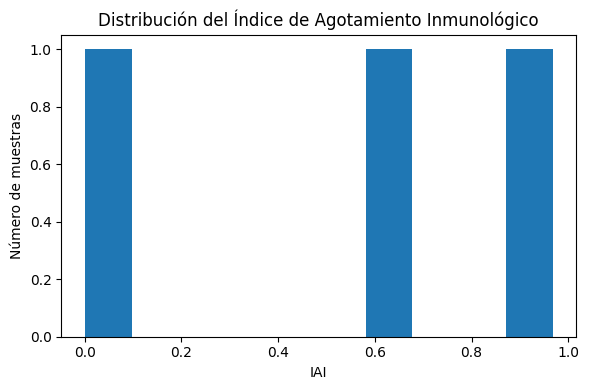

In [46]:
plt.figure(figsize=(6, 4))
plt.hist(final_report["IAI"], bins=10)
plt.xlabel("IAI")
plt.ylabel("Número de muestras")
plt.title("Distribución del Índice de Agotamiento Inmunológico")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "iai_distribution.png", dpi=300)
plt.show()

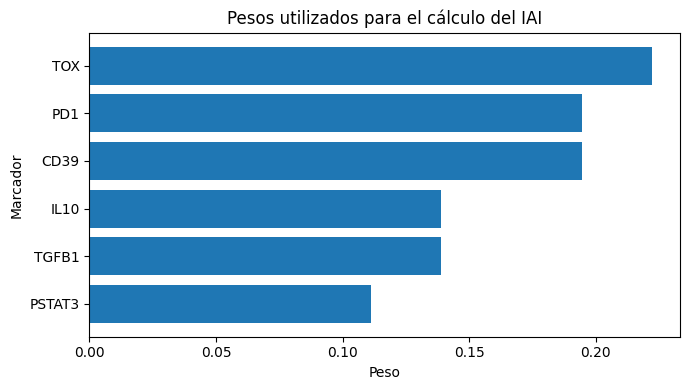

In [47]:
weights_plot = weights_used.sort_values("weight", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(weights_plot["marker_id"], weights_plot["weight"])
plt.xlabel("Peso")
plt.ylabel("Marcador")
plt.title("Pesos utilizados para el cálculo del IAI")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "iai_weights.png", dpi=300)
plt.show()

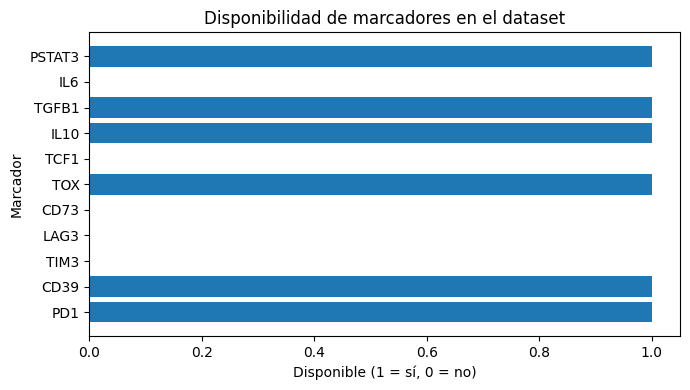

In [48]:
availability = validation_report.copy()
availability["available_numeric"] = availability["available"].astype(int)

plt.figure(figsize=(7, 4))
plt.barh(availability["marker_id"], availability["available_numeric"])
plt.xlabel("Disponible (1 = sí, 0 = no)")
plt.ylabel("Marcador")
plt.title("Disponibilidad de marcadores en el dataset")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "marker_availability.png", dpi=300)
plt.show()